# Improved QA-PINN for 1-D Viscous Burgers — Physics-Guided Redesign & XAI
**Workflow**

1. Recap Stage I/II — why the PDE demands a new architecture
2. Implement the improved architecture (`ImprovedQAPINN`)
3. **Circuit-depth hyperparameter tuning** (+ re-uploading depth)
4. Train the recommended improved model
5. Accuracy vs FEM & vs baseline / classical
6. Fourier expressivity (reuse `xai.expressivity`)
7. Entanglement (reuse `xai.quantum_metrics`)
8. Effective dimension / information bottleneck (reuse `xai.quantum_metrics`)
9. Barren-plateau / gradient-variance diagnostics (reuse `xai.landscapes`)
10. **Hidden-layer visualization** — QA-PINN (baseline + improved) and classical PINN
11. Final comparison report

### Step 0 — Setup

In [1]:
import os, sys, json, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pennylane as qml

ROOT = os.path.abspath(os.getcwd())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from xai import models, expressivity, quantum_metrics, landscapes, visualizer
from xai import physics_guided_burgers as pgb
from xai.common import load_features, PHYSICS, FeatureBundle, flat_grid

OUT = os.path.join(ROOT, "output", "qpinn_improved")
os.makedirs(OUT, exist_ok=True)
torch.manual_seed(0); np.random.seed(0)
DEVICE = "cpu"
print("torch", torch.__version__, "| pennylane", qml.__version__, "| figures ->", os.path.relpath(OUT, ROOT))

torch 2.12.1+cu130 | pennylane 0.45.1 | figures -> output/qpinn_improved


### Step 1 — Why a new architecture? (Stage I → Stage II recap)

The framework maps the PDE to a mathematical descriptor `D` (Stage I) and then deterministically
to an architecture (Stage II). We reuse that map to obtain the target design. The **baseline
QA-PINN's** documented failure (`rel-L2 ≈ 0.43`, ~77× worse than classical) is traced to a
*spectrally impoverished single-RY encoding*; the prescription is data re-uploading, ring
entanglement on every layer, and a widened decoder.

In [2]:
fb = load_features()
print(f"Feature bundle: baseline QA-PINN = {fb.n_qubits} qubits, {fb.n_layers} layers, FEM grid {fb.U_grid.shape}")

desc = pgb.burgers_descriptor(fb.U_grid, fb.x_grid, nu=PHYSICS.nu)
dx = float(np.mean(np.diff(fb.x_grid)))
freqs, P = pgb.power_spectrum(fb.U_grid, dx=dx)
Cs = pgb.spectral_complexity(P, freqs)
ks = pgb.shock_frequency(P, freqs)
rec = pgb.recommend_architecture(desc)

print(desc.summary())
print(f"\nSpectral complexity C_s = {Cs:.3f} | shock band k_s = {ks:.2f} cyc/x\n")
print(rec.summary())
print("\nRationale (PDE -> architecture):")
for k, v in rec.rationale.items():
    print(f"  [{k}] {v}")

Feature bundle: baseline QA-PINN = 3 qubits, 8 layers, FEM grid (501, 301)
Burgers descriptor (nu=0.01): d=2, order=2, linearity L=0.70, coupling C=0.50, boundary B=0.10, spectral C_s=0.233, shock S=39.27, shock-freq k_s=2.99 cyc/x

Spectral complexity C_s = 0.233 | shock band k_s = 2.99 cyc/x

Physics-guided architecture recommendation
  encoding            : angle+reuploading (L=4 re-uploading blocks)
  qubits              : 4
  circuit depth       : 6 variational layers
  entanglement        : ring (every layer)
  decoder hidden width: 16

Rationale (PDE -> architecture):
  [encoding] moderate C_s: angle + data re-uploading enlarges the accessible Fourier set (Perez-Salinas 2020); qubit count cannot (Schuld-Sweke-Meyer).
  [reuploading] L=4: degree of the accessible Fourier series must cover the shock band k_s=3.0 cyc/x.
  [qubits] n=4 from input dim 2 + coupling; adding qubits without spectral richness only inflates the 2^n space.
  [depth] depth=6 from order 2 + nonlinearity 0.70;

### Step 2 — Implement the improved architecture

`ImprovedQAPINN` realises the Stage-II recommendation. Differences vs the baseline
`xai.models.QAPINN` (mapped to the report's diagnosed failure modes):

| aspect | baseline `QAPINN` | **`ImprovedQAPINN`** | fixes |
|---|---|---|---|
| encoding | single RY layer | **RY data re-uploading every layer** | spectrally-impoverished feature map |
| encoding freq. | fixed | **trainable per-layer scales** `s_{l,i}` | enlarges accessible Fourier set |
| rotations | RX only | **RX + RZ** (fuller Bloch coverage) | restricted single-axis rotation |
| entanglement | ring on **even** layers | **ring on every layer** | entanglement suppression during training |
| decoder | `2**n → 2**(n-1) → 1` (pinch) | **`2**n → H → H/2 → 1`, wider `H`** | decoder pinch-point bottleneck |

The class keeps the **same public interface** as `xai.models.QAPINN`
(`.angles`, `.forward(..., return_features=True)`, `.n_qubits`, `.n_layers`, `.qlayer`),
so the existing `xai` metrics operate on it unchanged.

In [3]:
def make_improved_qnode(n_qubits, n_layers, state=False):
    # Improved ansatz: data re-uploading + trainable freq. + RX/RZ + ring-every-layer.
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights, scales):
        for l in range(n_layers):
            for i in range(n_qubits):                      # data RE-UPLOADING every layer
                qml.RY(scales[l, i] * inputs[..., i], wires=i)
            for i in range(n_qubits):                      # full-rotation variational sublayer
                qml.RX(weights[l, i, 0], wires=i)
                qml.RZ(weights[l, i, 1], wires=i)
            if n_qubits > 1:                               # RING entanglement EVERY layer
                for i in range(n_qubits):
                    qml.CNOT(wires=[i, (i + 1) % n_qubits])
        return qml.state() if state else qml.probs(wires=range(n_qubits))
    return circuit


class ImprovedQAPINN(nn.Module):
    def __init__(self, n_qubits=4, n_layers=6, decoder_hidden=32):
        super().__init__()
        self.n_qubits, self.n_layers = n_qubits, n_layers
        self.reuploading_blocks = n_layers            # one data upload per layer
        self.encoder = nn.Linear(2, n_qubits)
        qnode = make_improved_qnode(n_qubits, n_layers)
        self.qlayer = qml.qnn.TorchLayer(
            qnode, {"weights": (n_layers, n_qubits, 2), "scales": (n_layers, n_qubits)})
        H = max(decoder_hidden, 2 ** n_qubits)        # widened decoder (avoid the 2^(n-1) pinch)
        self.dec_fc1 = nn.Linear(2 ** n_qubits, H)
        self.dec_fc2 = nn.Linear(H, H // 2)
        self.dec_fc3 = nn.Linear(H // 2, 1)
        self.dec_act = nn.Tanh()
        with torch.no_grad():
            self.qlayer.scales.fill_(1.0)             # start at base encoding frequency

    def angles(self, x, t):
        return np.pi * torch.tanh(self.encoder(torch.cat([x, t], dim=1)))

    def forward(self, x, t, return_features=False):
        enc_pre = self.encoder(torch.cat([x, t], dim=1))
        angles = np.pi * torch.tanh(enc_pre)
        probs = self.qlayer(angles)
        h1 = self.dec_act(self.dec_fc1(probs))
        h2 = self.dec_act(self.dec_fc2(h1))
        u = self.dec_fc3(h2)
        if return_features:
            return u, {"encoder_pre": enc_pre.detach(), "encoder_angles": angles.detach(),
                       "quantum_probs": probs.detach(), "decoder_hidden": h2.detach(),
                       "output": u.detach()}
        return u


def improved_states(model, xn, tn, idx):
    # Statevectors of the improved circuit at encoder angles for grid rows `idx`.
    sq = make_improved_qnode(model.n_qubits, model.n_layers, state=True)
    with torch.no_grad():
        a = model.angles(xn[idx], tn[idx])
        return sq(a, model.qlayer.weights.detach(), model.qlayer.scales.detach()).numpy()


# baseline QA-PINN + classical PINN for comparison (loaded, never modified)
baseline, _ = models.load_qapinn(fb.n_qubits)
classical, _ = models.load_classical()

improved = ImprovedQAPINN(rec.n_qubits, rec.circuit_depth, rec.decoder_hidden)
def nparams(m): return sum(p.numel() for p in m.parameters())
print(f"{'model':<22}{'qubits':<8}{'layers':<8}{'params':<8}")
print(f"{'Classical PINN':<22}{'-':<8}{'-':<8}{nparams(classical):<8}")
print(f"{'Baseline QA-PINN':<22}{baseline.n_qubits:<8}{baseline.n_layers:<8}{nparams(baseline):<8}")
print(f"{'Improved QA-PINN':<22}{improved.n_qubits:<8}{improved.n_layers:<8}{nparams(improved):<8}")

# normalised full-grid coordinates (reused throughout)
x_col, t_col = flat_grid(fb.x_grid, fb.t_grid)
XN = torch.tensor(PHYSICS.norm_x(x_col), dtype=torch.float32)
TN = torch.tensor(PHYSICS.norm_t(t_col), dtype=torch.float32)

def rel_l2(model):
    with torch.no_grad():
        u = model(XN, TN).numpy().reshape(fb.U_grid.shape)
    return float(np.linalg.norm(u - fb.U_grid) / np.linalg.norm(fb.U_grid)), u

model                 qubits  layers  params  
Classical PINN        -       -       249     
Baseline QA-PINN      3       8       74      
Improved QA-PINN      4       6       501     


### Step 3 — Circuit-depth hyperparameter tuning

Because the improved ansatz re-uploads the data **once per variational layer**, the circuit depth
`D` doubles as the **re-uploading depth** `L`: by the Schuld–Sweke–Meyer theorem the accessible
Fourier degree grows with `L`, so `D` is the single highest-leverage knob. We sweep
`D ∈ {2, 4, 6, 8}` (short training each) and record accuracy, expressivity, entanglement,
effective dimension and gradient health, then pick the best-value depth.

In [4]:
def make_batch(model, seed, n_data=400, n_coll=400, n_bcic=120):
    xc, tc = pgb.sample_collocation(n_coll, "shock_aware", model=model, seed=seed)
    b = landscapes._fem_tensors(fb, n_data=n_data, n_coll=1, n_bcic=n_bcic, seed=seed)
    b["xc"], b["tc"] = xc, tc
    return b

def train_improved(model, epochs, lr=3e-3, light=True, verbose=False):
    # Train `model`; `light` uses base+spectral loss only (fast, for the sweep).
    cfg = pgb.PhysicsGuidedLossConfig(
        use_entanglement=False,
        use_measurement=(not light), use_effdim=(not light),
        use_spectral=True, use_encoding=False, use_depth=False)
    loss_fn = pgb.PhysicsGuidedLoss(model, cfg, shock_frequency=ks)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist = {"total": [], "L_pde": [], "L_data": [], "rel_l2": []}
    for ep in range(epochs):
        b = make_batch(model, ep)
        opt.zero_grad(); total, comp = loss_fn(b); total.backward(); opt.step(); sched.step()
        for k in ("total", "L_pde", "L_data"):
            hist[k].append(comp.get(k, 0.0))
        if verbose and (ep % 50 == 0 or ep == epochs - 1):
            r, _ = rel_l2(model)
            hist["rel_l2"].append(r)
            print(f"  ep {ep:3d}  total={comp['total']:.4f}  L_pde={comp.get('L_pde',0):.4f}  rel-L2={r:.4f}")
    return hist

SWEEP_DEPTHS = [2, 4, 6, 8]
SWEEP_EPOCHS = 100
sweep = []
t0 = time.time()
for D in SWEEP_DEPTHS:
    torch.manual_seed(0); np.random.seed(0)
    m = ImprovedQAPINN(rec.n_qubits, D, rec.decoder_hidden)
    train_improved(m, SWEEP_EPOCHS, light=True)
    r, _ = rel_l2(m)
    # expressivity (reuse xai.expressivity)
    fsp = expressivity.fourier_spectrum(m, f"D={D}", axis="x", fixed=0.5, n=256, is_quantum=True)
    # entanglement (improved states + reused meyer_wallach)
    ridx = np.random.default_rng(0).choice(XN.shape[0], size=96, replace=False)
    st = improved_states(m, XN, TN, ridx)
    Q = float(np.mean([quantum_metrics.meyer_wallach(s, m.n_qubits) for s in st]))
    # effective dimension of quantum probs (reuse)
    with torch.no_grad():
        _, ft = m(XN[ridx], TN[ridx], return_features=True)
    deff = quantum_metrics.effective_dimension(ft["quantum_probs"].numpy())["effective_dimension"]
    sweep.append(dict(depth=D, params=nparams(m), rel_l2=r, Q=Q, d_eff=deff,
                      out_maxfreq=fsp["output_summary"]["max_frequency"],
                      q_maxfreq=fsp["quantum_probs_summary"]["max_frequency"]))
    print(f"D={D:2d}  params={nparams(m):4d}  rel-L2={r:.4f}  Q={Q:.3f}  d_eff={deff:.2f}  "
          f"q_maxfreq={fsp['quantum_probs_summary']['max_frequency']:.1f}")
best_depth = min(sweep, key=lambda s: s["rel_l2"])["depth"]
print(f"\nSweep done in {time.time()-t0:.0f}s. Best-accuracy depth = {best_depth}  "
      f"(Stage-II recommended depth = {rec.circuit_depth})")

D= 2  params= 453  rel-L2=0.8202  Q=0.822  d_eff=4.20  q_maxfreq=13.9
D= 4  params= 477  rel-L2=0.6935  Q=0.815  d_eff=5.80  q_maxfreq=12.9
D= 6  params= 501  rel-L2=0.7254  Q=0.810  d_eff=5.70  q_maxfreq=15.9
D= 8  params= 525  rel-L2=0.8583  Q=0.765  d_eff=5.82  q_maxfreq=15.9

Sweep done in 296s. Best-accuracy depth = 4  (Stage-II recommended depth = 6)


In [5]:
Ds = [s["depth"] for s in sweep]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].plot(Ds, [s["rel_l2"] for s in sweep], "o-", color="#C44E52", lw=2)
ax[0].axhline(0.427, ls="--", color="#4D4D4D", label="baseline QA-PINN (0.427)")
ax[0].set_xlabel("circuit depth D (= re-uploading blocks L)"); ax[0].set_ylabel("rel-L2 vs FEM")
ax[0].set_title("Accuracy vs circuit depth"); ax[0].set_xticks(Ds); ax[0].legend()

axb = ax[1].twinx()
ax[1].plot(Ds, [s["q_maxfreq"] for s in sweep], "o-", color="#4C72B0", lw=2, label="quantum max freq")
axb.plot(Ds, [s["Q"] for s in sweep], "s--", color="#55A868", lw=2, label="Meyer-Wallach Q")
ax[1].set_xlabel("circuit depth D"); ax[1].set_ylabel("quantum feature-map max freq", color="#4C72B0")
axb.set_ylabel("Meyer-Wallach Q", color="#55A868")
ax[1].set_title("Expressivity & entanglement vs depth"); ax[1].set_xticks(Ds)
ax[1].grid(False); axb.grid(False)
l1, la = ax[1].get_legend_handles_labels(); l2, lb = axb.get_legend_handles_labels()
ax[1].legend(l1 + l2, la + lb, fontsize=9, loc="upper left")

axc = ax[2].twinx()
ax[2].plot(Ds, [s["d_eff"] for s in sweep], "o-", color="#8172B3", lw=2, label="effective dim")
axc.plot(Ds, [s["params"] for s in sweep], "s--", color="#888", lw=2, label="params")
ax[2].set_xlabel("circuit depth D"); ax[2].set_ylabel("effective dim of quantum probs", color="#8172B3")
axc.set_ylabel("parameter count", color="#888")
ax[2].set_title("Capacity vs depth"); ax[2].set_xticks(Ds)
ax[2].grid(False); axc.grid(False)
l1, la = ax[2].get_legend_handles_labels(); l2, lb = axc.get_legend_handles_labels()
ax[2].legend(l1 + l2, la + lb, fontsize=9, loc="upper left")

fig.suptitle("Step 3 — Circuit-depth hyperparameter tuning (Improved QA-PINN)", y=1.02, fontsize=13)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "step3_depth_sweep.png"), dpi=150, bbox_inches="tight")
plt.show()

### Step 4 — Train the recommended improved model

We train the Stage-II design (`n_qubits`, `circuit_depth`, widened decoder) for longer under the
unified `PhysicsGuidedLoss` (base terms + shock-preserving spectral penalty + measurement / effective-
dimension regularisers) with shock-aware adaptive collocation. The trained weights and the extracted
layer-wise features are cached for the analyses that follow.

In [6]:
torch.manual_seed(0); np.random.seed(0)
improved = ImprovedQAPINN(rec.n_qubits, rec.circuit_depth, rec.decoder_hidden)
FINAL_EPOCHS = 300
print(f"Training improved {improved.n_qubits}q / {improved.n_layers}L "
      f"({nparams(improved)} params) for {FINAL_EPOCHS} epochs ...")
hist = train_improved(improved, FINAL_EPOCHS, lr=3e-3, light=False, verbose=True)

rel_improved, U_improved = rel_l2(improved)
print(f"\nImproved QA-PINN rel-L2 vs FEM = {rel_improved:.4f}")

# cache checkpoint + features for reproducibility
ckpt_path = os.path.join(ROOT, "checkpoints", "qapinn_improved.pt")
torch.save({"state_dict": improved.state_dict(),
            "architecture": {"n_qubits": improved.n_qubits, "n_layers": improved.n_layers,
                             "decoder_hidden": rec.decoder_hidden},
            "metrics": {"rel_l2_vs_fem": rel_improved, "n_params": nparams(improved)}}, ckpt_path)
print("Saved ->", os.path.relpath(ckpt_path, ROOT))

Training improved 4q / 6L (501 params) for 300 epochs ...
  ep   0  total=7.4969  L_pde=0.0098  rel-L2=1.2047
  ep  50  total=2.3996  L_pde=0.4662  rel-L2=0.7581
  ep 100  total=0.7951  L_pde=0.4724  rel-L2=0.4282
  ep 150  total=0.6498  L_pde=0.4028  rel-L2=0.3981
  ep 200  total=0.6996  L_pde=0.4522  rel-L2=0.3935
  ep 250  total=0.5653  L_pde=0.3485  rel-L2=0.3942
  ep 299  total=0.6455  L_pde=0.4034  rel-L2=0.3928

Improved QA-PINN rel-L2 vs FEM = 0.3928
Saved -> checkpoints/qapinn_improved.pt


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(hist["total"], color="#4C72B0", lw=1.5, label="total")
ax[0].plot(hist["L_pde"], color="#C44E52", lw=1.5, label="PDE residual")
ax[0].plot(hist["L_data"], color="#55A868", lw=1.5, label="data")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("Training dynamics"); ax[0].legend()

# improved features on full grid, cached for reuse
with torch.no_grad():
    _, FEAT = improved(XN, TN, return_features=True)
FEAT = {k: v.numpy() for k, v in FEAT.items()}
fb_improved = FeatureBundle(
    x_grid=fb.x_grid, t_grid=fb.t_grid, U_grid=fb.U_grid, U_qapinn=U_improved,
    n_qubits=improved.n_qubits, n_layers=improved.n_layers,
    encoder_pre=FEAT["encoder_pre"], encoder_angles=FEAT["encoder_angles"],
    quantum_probs=FEAT["quantum_probs"], decoder_hidden=FEAT["decoder_hidden"],
    output=FEAT["output"])

im = ax[1].imshow(U_improved, aspect="auto", origin="lower", cmap="viridis",
                  extent=[fb.x_grid[0], fb.x_grid[-1], fb.t_grid[0], fb.t_grid[-1]])
ax[1].set_xlabel("x"); ax[1].set_ylabel("t"); ax[1].set_title(f"Improved QA-PINN u(x,t)  (rel-L2={rel_improved:.3f})")
fig.colorbar(im, ax=ax[1])
fig.tight_layout(); fig.savefig(os.path.join(OUT, "step4_training.png"), dpi=150, bbox_inches="tight")
plt.show()

### Step 5 — Accuracy vs FEM, baseline and classical

Solution-field comparison and the headline accuracy table. The improved architecture is expected to
**beat the baseline QA-PINN** while remaining well above the classical PINN — confirming the report's
thesis that the physics-guided fixes help but the quantum feature map's fundamental ceiling remains.

In [8]:
rel_baseline, U_baseline = rel_l2(baseline)
rel_classical, U_classical = rel_l2(classical)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
X, T = np.meshgrid(fb.x_grid, fb.t_grid)
panels = [(fb.U_grid, "FEM reference", "viridis"),
          (U_classical, f"Classical PINN (rel-L2={rel_classical:.3f})", "viridis"),
          (U_baseline, f"Baseline QA-PINN (rel-L2={rel_baseline:.3f})", "viridis"),
          (U_improved, f"Improved QA-PINN (rel-L2={rel_improved:.3f})", "viridis")]
for ax, (fld, title, cmap) in zip(axes, panels):
    pc = ax.pcolormesh(X, T, fld, shading="auto", cmap=cmap)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title, fontsize=10)
    fig.colorbar(pc, ax=ax)
fig.suptitle("Step 5 — Solution fields", y=1.03, fontsize=13)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "step5_fields.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"{'model':<22}{'rel-L2 vs FEM':<16}{'params':<8}")
print("-" * 46)
print(f"{'Classical PINN':<22}{rel_classical:<16.3e}{nparams(classical):<8}")
print(f"{'Baseline QA-PINN':<22}{rel_baseline:<16.3e}{nparams(baseline):<8}")
print(f"{'Improved QA-PINN':<22}{rel_improved:<16.3e}{nparams(improved):<8}")
imp = 100 * (rel_baseline - rel_improved) / rel_baseline
print(f"\nImproved vs baseline QA-PINN: {imp:+.1f}% relative-L2 change")

model                 rel-L2 vs FEM   params  
----------------------------------------------
Classical PINN        3.335e-03       249     
Baseline QA-PINN      4.277e-01       74      
Improved QA-PINN      3.928e-01       501     

Improved vs baseline QA-PINN: +8.2% relative-L2 change


### Step 6 — Fourier expressivity (reuse `xai.expressivity`)

`expressivity.fourier_spectrum` is applied unchanged to all three models. The key panel is the
**quantum feature-map spectrum**: the baseline's single-RY map is confined to a few low harmonics,
while re-uploading + trainable frequencies should populate a much wider band (reaching the shock
band `k_s`).

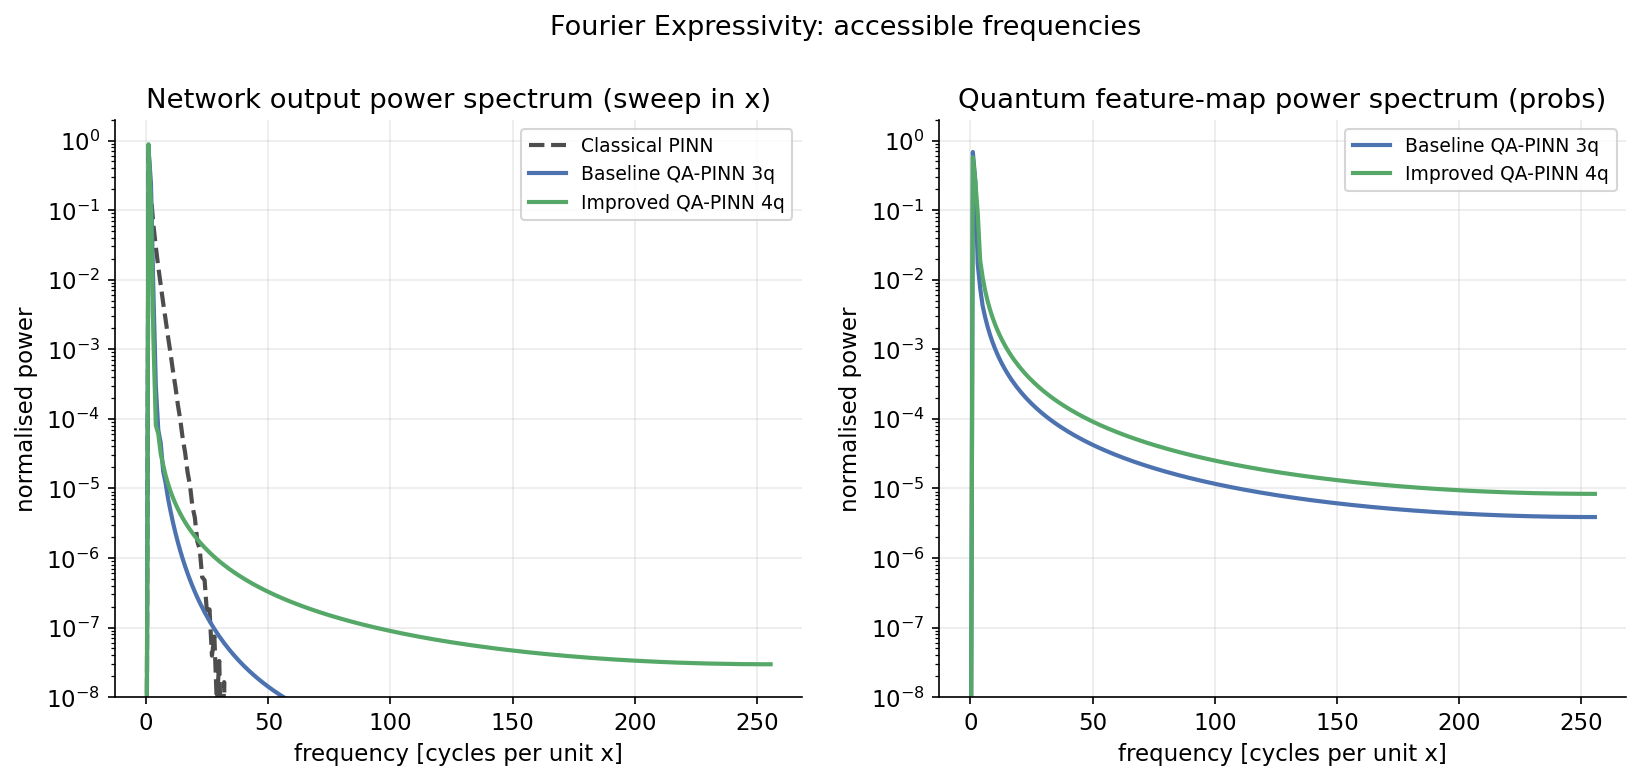

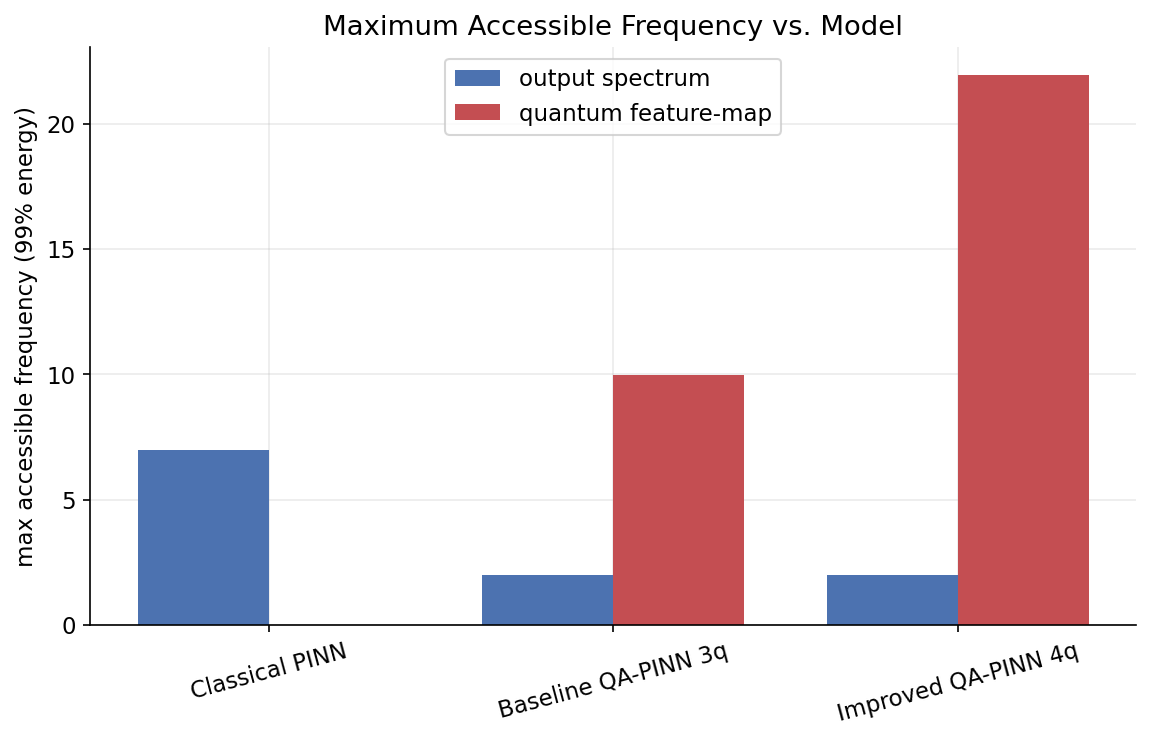

Max accessible frequency (99% energy):
  Classical PINN         output=  6.99   quantum-map=   nan
  Baseline QA-PINN 3q    output=  2.00   quantum-map=  9.98
  Improved QA-PINN 4q    output=  2.00   quantum-map= 21.96

Shock band the encoding must reach: k_s = 2.99 cyc/x


In [9]:
spectra = {
    "Classical PINN": expressivity.fourier_spectrum(classical, "Classical PINN", "x", 0.5, 512),
    "Baseline QA-PINN 3q": expressivity.fourier_spectrum(baseline, "Baseline QA-PINN 3q", "x", 0.5, 512, is_quantum=True),
    "Improved QA-PINN 4q": expressivity.fourier_spectrum(improved, "Improved QA-PINN 4q", "x", 0.5, 512, is_quantum=True),
}
# summary table (same shape visualizer expects)
spectra["_summary_table"] = []
for lab, r in spectra.items():
    if lab.startswith("_"): continue
    row = {"model": lab, **r["output_summary"]}
    if "quantum_probs_summary" in r:
        row["quantum_max_frequency"] = r["quantum_probs_summary"]["max_frequency"]
    spectra["_summary_table"].append(row)

p1 = visualizer.plot_fourier_spectra(spectra, OUT, "x")
p2 = visualizer.plot_max_frequency_bar(spectra, OUT)
from IPython.display import Image, display
for p in (p1, p2): display(Image(p))

print("Max accessible frequency (99% energy):")
for row in spectra["_summary_table"]:
    q = row.get("quantum_max_frequency", float("nan"))
    print(f"  {row['model']:<22} output={row['max_frequency']:6.2f}   quantum-map={q:6.2f}")
print(f"\nShock band the encoding must reach: k_s = {ks:.2f} cyc/x")

### Step 7 — Entanglement analysis (reuse `xai.quantum_metrics`)

Meyer–Wallach `Q` and mean bipartite von-Neumann entropy over the Burgers domain. The baseline uses
`quantum_metrics.entanglement_over_domain` directly; the improved model reuses the same
`meyer_wallach` / `mean_bipartite_entropy` primitives on statevectors produced by *its* circuit. The
report's "smoking gun" is that training drives baseline entanglement down — ring-every-layer should
keep the improved model in a strongly-entangled regime.

In [10]:
ent_base = quantum_metrics.entanglement_over_domain(baseline, fb, n_samples=256, seed=0)
ridx = np.random.default_rng(0).choice(XN.shape[0], size=256, replace=False)
st = improved_states(improved, XN, TN, ridx)
Qi = [quantum_metrics.meyer_wallach(s, improved.n_qubits) for s in st]
Si = [quantum_metrics.mean_bipartite_entropy(s, improved.n_qubits) for s in st]
ent_imp = {"meyer_wallach_mean": float(np.mean(Qi)), "meyer_wallach_std": float(np.std(Qi)),
           "bipartite_entropy_mean": float(np.mean(Si)), "bipartite_entropy_std": float(np.std(Si))}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
labels = ["Baseline\nQA-PINN 3q", "Improved\nQA-PINN 4q"]
Qm = [ent_base["meyer_wallach_mean"], ent_imp["meyer_wallach_mean"]]
Qe = [ent_base["meyer_wallach_std"], ent_imp["meyer_wallach_std"]]
Sm = [ent_base["bipartite_entropy_mean"], ent_imp["bipartite_entropy_mean"]]
Se = [ent_base["bipartite_entropy_std"], ent_imp["bipartite_entropy_std"]]
ax[0].bar(labels, Qm, yerr=Qe, capsize=5, color=["#4D4D4D", "#4C72B0"])
ax[0].set_ylabel("Meyer-Wallach Q"); ax[0].set_title("Global entanglement over domain"); ax[0].set_ylim(0, 1)
ax[1].bar(labels, Sm, yerr=Se, capsize=5, color=["#4D4D4D", "#55A868"])
ax[1].set_ylabel("mean bipartite entropy [bits]"); ax[1].set_title("Bipartite von-Neumann entropy")
fig.suptitle("Step 7 — Entanglement: baseline vs improved", y=1.02, fontsize=13)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "step7_entanglement.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Meyer-Wallach Q : baseline {ent_base['meyer_wallach_mean']:.3f}  ->  improved {ent_imp['meyer_wallach_mean']:.3f}")
print(f"Bipartite S     : baseline {ent_base['bipartite_entropy_mean']:.3f}  ->  improved {ent_imp['bipartite_entropy_mean']:.3f} bits")

Meyer-Wallach Q : baseline 0.568  ->  improved 0.828
Bipartite S     : baseline 0.566  ->  improved 1.033 bits


### Step 8 — Effective dimension / information bottleneck (reuse `xai.quantum_metrics`)

`information_bottleneck` runs the SVD / participation-ratio analysis across the whole hybrid pipeline;
`effective_dimension_report` and `circuit_complexity_metrics` add the covariance eigen-spectrum and
Hilbert-space-utilisation ratios. We compare the baseline bundle (`fb`) with the improved bundle
(`fb_improved`) built in Step 4.

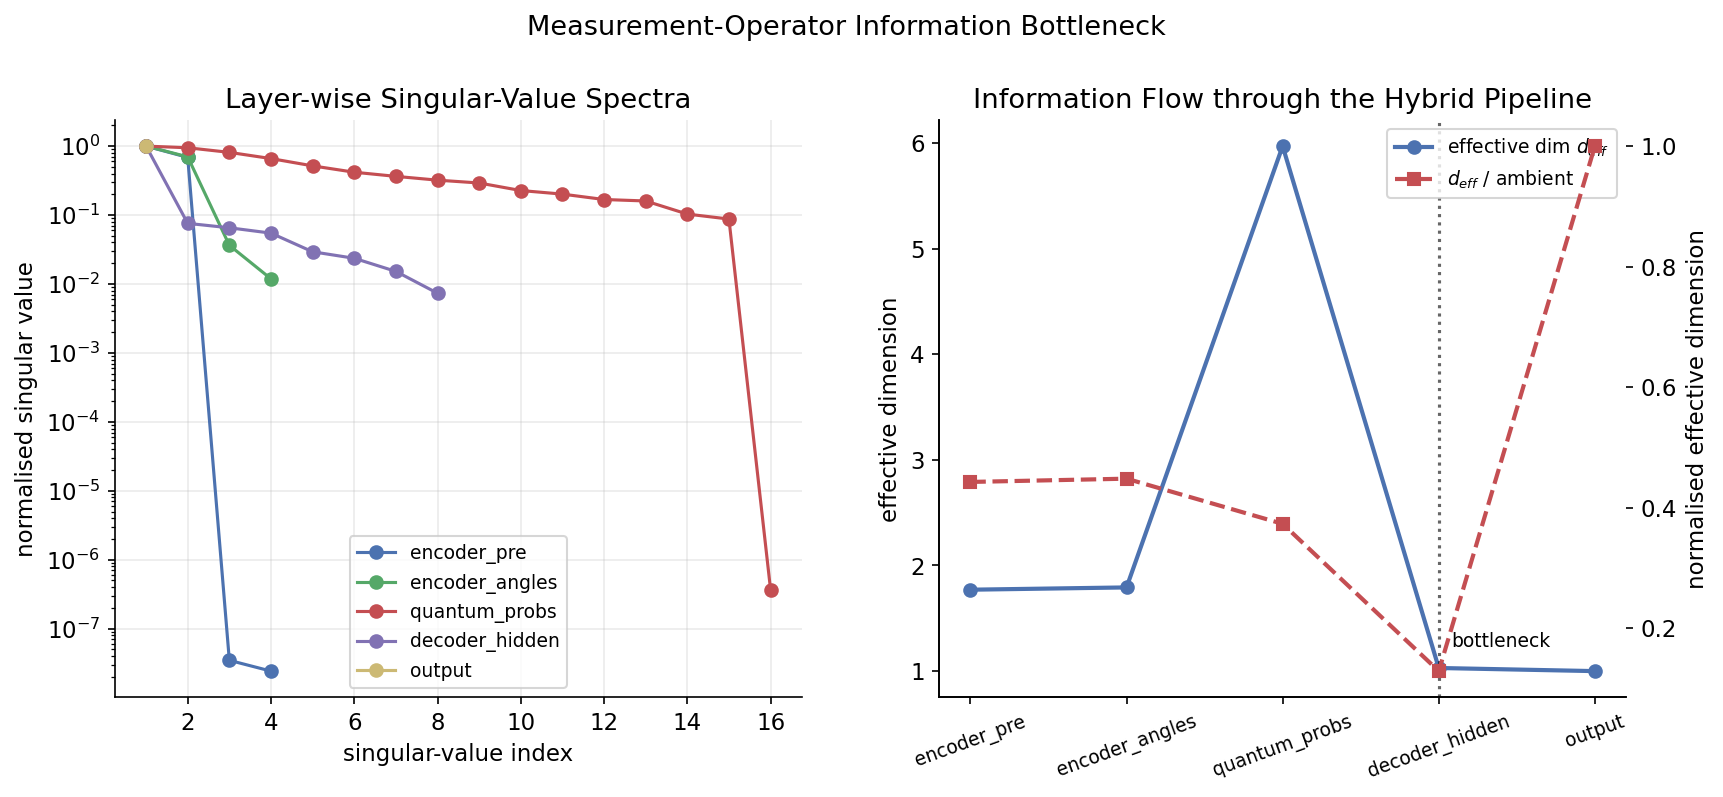

quantity                      baseline 3q     improved 4q     
--------------------------------------------------------------
Hilbert dim (2^n)             8               16              
quantum-probs d_eff           3.25            5.94            
intrinsic dim (90% var)       4               7               
Hilbert utilisation           0.407           0.371           
bottleneck layer              decoder_hidden  decoder_hidden  


In [11]:
ib_base = quantum_metrics.information_bottleneck(fb)
ib_imp = quantum_metrics.information_bottleneck(fb_improved)
p_ib = visualizer.plot_information_bottleneck(ib_imp, OUT)
display(Image(p_ib))

edr_base = pgb.effective_dimension_report(fb.quantum_probs)
edr_imp = pgb.effective_dimension_report(fb_improved.quantum_probs)
cc_imp = pgb.circuit_complexity_metrics(
    improved.n_qubits, improved.n_layers, reuploading_blocks=improved.reuploading_blocks,
    effective_dim=edr_imp["effective_dimension"], target_depth=rec.circuit_depth)

print(f"{'quantity':<30}{'baseline 3q':<16}{'improved 4q':<16}")
print("-" * 62)
print(f"{'Hilbert dim (2^n)':<30}{2**fb.n_qubits:<16}{2**improved.n_qubits:<16}")
print(f"{'quantum-probs d_eff':<30}{edr_base['effective_dimension']:<16.2f}{edr_imp['effective_dimension']:<16.2f}")
print(f"{'intrinsic dim (90% var)':<30}{edr_base['intrinsic_dimension']:<16}{edr_imp['intrinsic_dimension']:<16}")
print(f"{'Hilbert utilisation':<30}{edr_base['effective_dimension']/2**fb.n_qubits:<16.3f}{cc_imp['hilbert_utilisation']:<16.3f}")
print(f"{'bottleneck layer':<30}{ib_base['bottleneck_layer']:<16}{ib_imp['bottleneck_layer']:<16}")

### Step 9 — Barren-plateau & gradient-variance diagnostics (reuse `xai.landscapes`)

`landscapes.barren_plateau_scan` measures how the variational-gradient variance decays with qubit
count (the baseline ansatz). We also report the improved model's per-parameter-group gradient RMS to
check the quantum core is being trained (not stuck on a plateau).

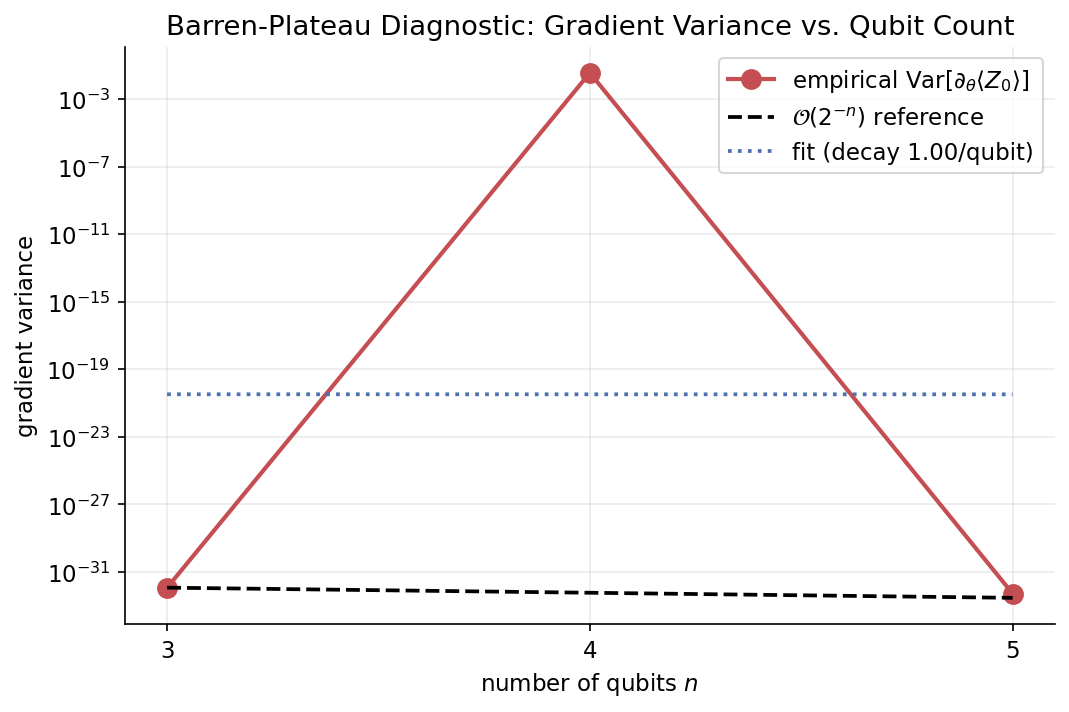

Gradient-variance decay factor per qubit = 0.997 (0.5 == ideal barren plateau)

Improved QA-PINN gradient RMS by group (PDE residual):
  encoder    grad_rms=7.975e-01  (12 params)
  quantum    grad_rms=1.882e-01  (72 params)
  decoder    grad_rms=7.948e-02  (417 params)


ImprovedQAPINN(
  (encoder): Linear(in_features=2, out_features=4, bias=True)
  (qlayer): <Quantum Torch Layer: func=circuit>
  (dec_fc1): Linear(in_features=16, out_features=16, bias=True)
  (dec_fc2): Linear(in_features=16, out_features=8, bias=True)
  (dec_fc3): Linear(in_features=8, out_features=1, bias=True)
  (dec_act): Tanh()
)

In [12]:
bp = landscapes.barren_plateau_scan((3, 4, 5), seed=0)
p_bp = visualizer.plot_barren_plateau(bp, OUT)
display(Image(p_bp))
print(f"Gradient-variance decay factor per qubit = {bp['fit']['decay_factor_per_qubit']:.3f} "
      f"(0.5 == ideal barren plateau)")

# improved model gradient health on the PDE residual
improved.train()
xc = torch.tensor(np.random.uniform(-1, 1, (400, 1)), dtype=torch.float32, requires_grad=True)
tc = torch.tensor(np.random.uniform(-1, 1, (400, 1)), dtype=torch.float32, requires_grad=True)
u = improved(xc, tc)
u_t = torch.autograd.grad(u, tc, torch.ones_like(u), create_graph=True)[0] * PHYSICS.st
u_xh = torch.autograd.grad(u, xc, torch.ones_like(u), create_graph=True)[0]
u_xx = torch.autograd.grad(u_xh, xc, torch.ones_like(u_xh), create_graph=True)[0] * PHYSICS.sx**2
res = u_t + u * (u_xh * PHYSICS.sx) - PHYSICS.nu * u_xx
improved.zero_grad(); (res**2).mean().backward()
grp = {"encoder": ["encoder"], "quantum": ["qlayer"], "decoder": ["dec_fc"]}
print("\nImproved QA-PINN gradient RMS by group (PDE residual):")
for g, keys in grp.items():
    sq, cnt = 0.0, 0
    for n, p in improved.named_parameters():
        if any(k in n for k in keys) and p.grad is not None:
            sq += float((p.grad**2).sum()); cnt += p.numel()
    print(f"  {g:<10} grad_rms={np.sqrt(sq/max(cnt,1)):.3e}  ({cnt} params)")
improved.eval()

### Step 10 — Hidden-layer visualization

We open up the internal representations of all three networks at a fixed time slice `t = 0.5`:

* **Classical PINN** — the `tanh` activations of each hidden layer across `x`.
* **QA-PINN quantum layer** — the `2**n` measurement-probability channels across `x`.
* **QA-PINN decoder hidden** — the post-quantum classical hidden activations across `x`.

and then the **PCA / t-SNE embeddings** of the quantum measurement features (reusing
`visualizer.plot_feature_embeddings`), which show the quantum layer acting as a non-linear feature
extractor that organises the `(x,t)` domain.

In [13]:
# ---- 10a. activation maps along x at t = 0.5 ----
n = 200
xs = np.linspace(PHYSICS.xmin, PHYSICS.xmax, n)
xln = torch.tensor(PHYSICS.norm_x(xs).reshape(-1, 1), dtype=torch.float32)
tln = torch.tensor(np.full((n, 1), PHYSICS.norm_t(0.5)), dtype=torch.float32)

# classical hidden activations via forward hooks on each Linear
acts, hooks, li = {}, [], 0
def _tap(name):
    def h(m, i, o): acts[name] = o.detach().numpy()
    return h
for mod in classical.net:
    if isinstance(mod, nn.Linear):
        hooks.append(mod.register_forward_hook(_tap(f"L{li}"))); li += 1
with torch.no_grad(): classical(xln, tln)
for h in hooks: h.remove()
classical_hidden = [np.tanh(acts[f"L{k}"]) for k in range(li - 1)]  # tanh applied after each hidden Linear

with torch.no_grad():
    _, fbase = baseline(xln, tln, return_features=True)
    _, fimp = improved(xln, tln, return_features=True)

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
# classical: stack hidden layers (units x x)
cl_stack = np.concatenate(classical_hidden, axis=1).T
im = axes[0, 0].imshow(cl_stack, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1,
                       extent=[0, 1, cl_stack.shape[0], 0])
axes[0, 0].set_title(f"Classical PINN — {li-1} hidden layers (tanh)"); axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("hidden unit (stacked)"); fig.colorbar(im, ax=axes[0, 0])

for col, (feat, tag, nq) in enumerate([(fbase, "Baseline QA-PINN 3q", baseline.n_qubits),
                                       (fimp, "Improved QA-PINN 4q", improved.n_qubits)], start=1):
    qp = feat["quantum_probs"].numpy().T
    im = axes[0, col].imshow(qp, aspect="auto", cmap="magma", extent=[0, 1, qp.shape[0], 0])
    axes[0, col].set_title(f"{tag} — {2**nq} quantum-prob channels"); axes[0, col].set_xlabel("x")
    axes[0, col].set_ylabel("basis state"); fig.colorbar(im, ax=axes[0, col])

# bottom row: line profiles of a few channels + decoder hidden
axes[1, 0].plot(xs, np.tanh(acts[f"L{li-2}"]))
axes[1, 0].set_title("Classical PINN — last hidden layer activations"); axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("tanh activation")
for col, (feat, tag) in enumerate([(fbase, "Baseline QA-PINN"), (fimp, "Improved QA-PINN")], start=1):
    dh = feat["decoder_hidden"].numpy()
    axes[1, col].plot(xs, dh)
    axes[1, col].set_title(f"{tag} — decoder hidden activations"); axes[1, col].set_xlabel("x")
    axes[1, col].set_ylabel("tanh activation")
fig.suptitle("Step 10 — Hidden-layer activations at t = 0.5", y=1.01, fontsize=13)
fig.tight_layout(); fig.savefig(os.path.join(OUT, "step10_hidden_activations.png"), dpi=150, bbox_inches="tight")
plt.show()

Baseline QA-PINN (3q) quantum-feature embedding:


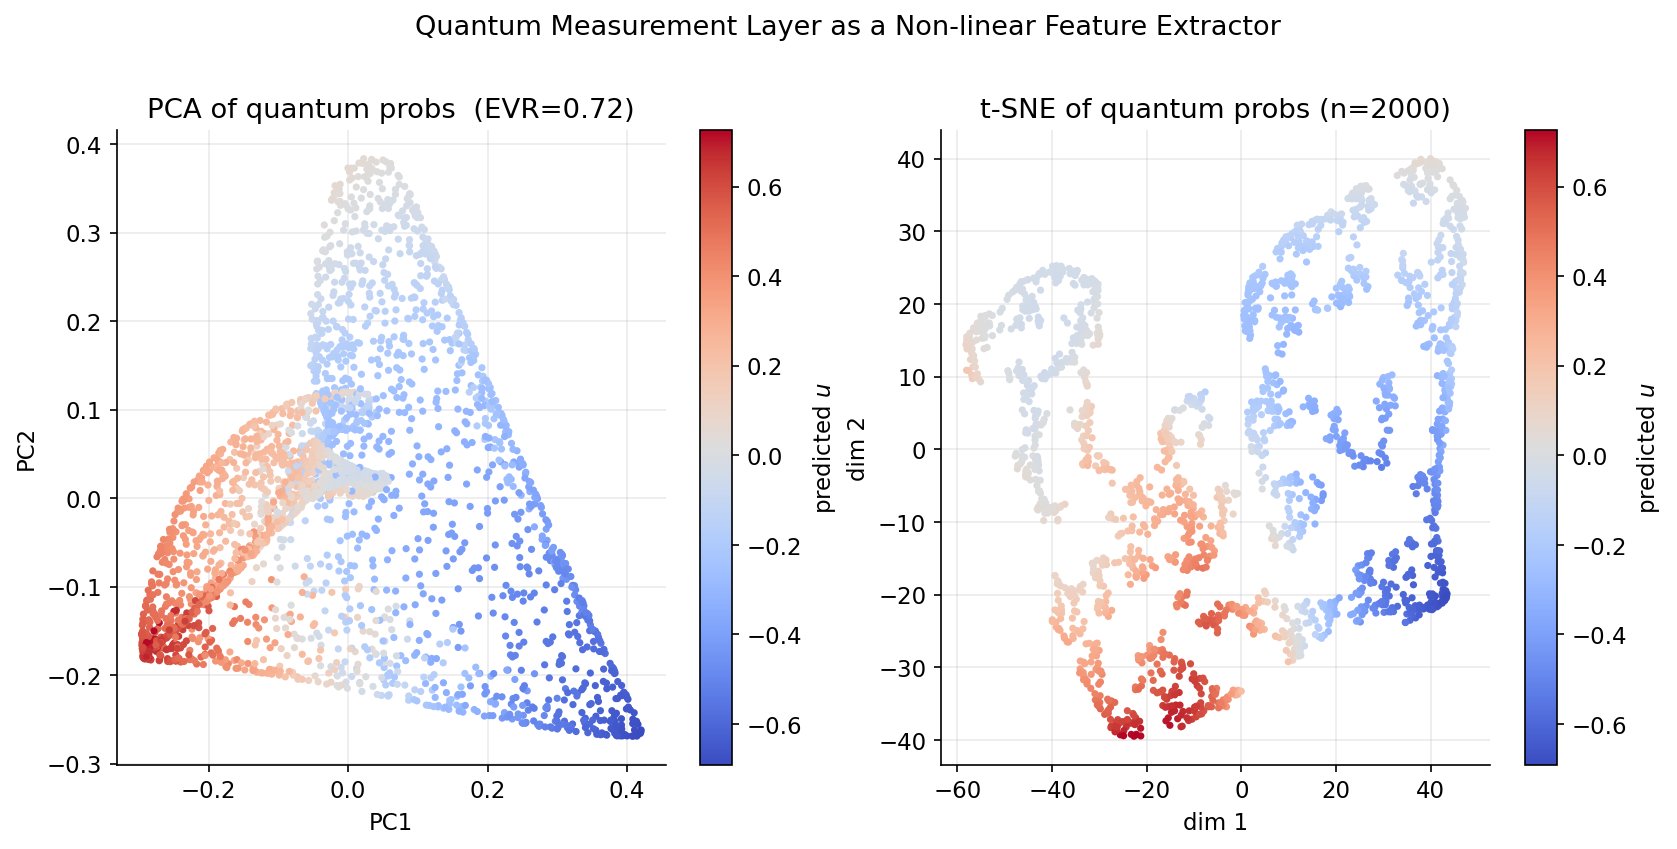

Improved QA-PINN (4q) quantum-feature embedding:


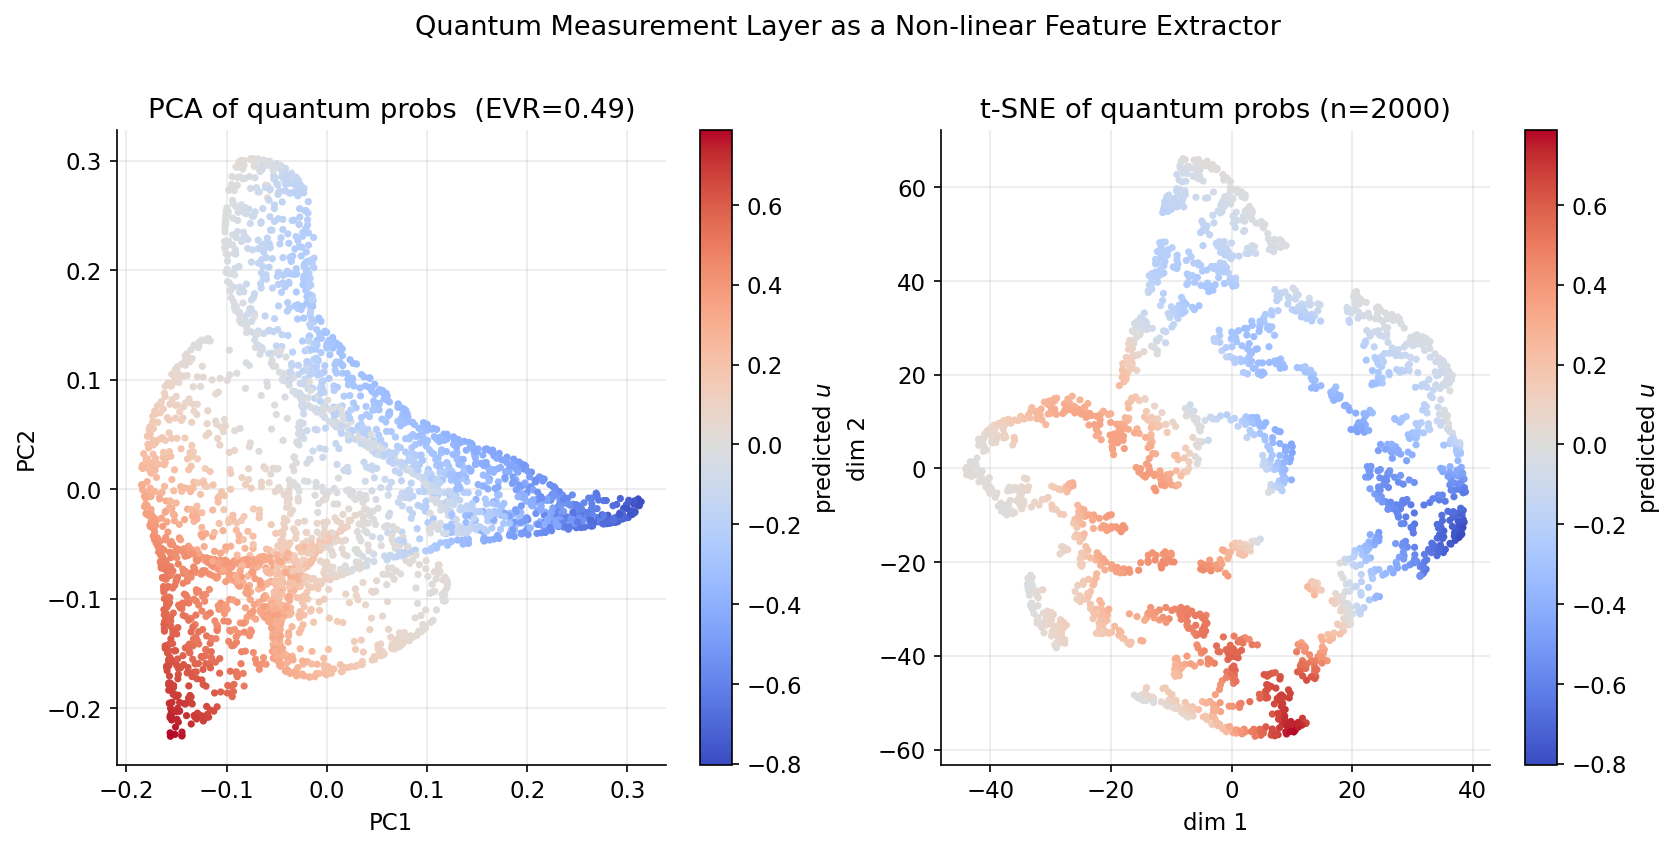

In [14]:
# ---- 10b. PCA / t-SNE of the quantum measurement features (reuse visualizer) ----
p_emb_base = visualizer.plot_feature_embeddings(fb, OUT, max_points=3000)
os.replace(p_emb_base, os.path.join(OUT, "step10_embeddings_baseline.png"))
p_emb_imp = visualizer.plot_feature_embeddings(fb_improved, OUT, max_points=3000)
os.replace(p_emb_imp, os.path.join(OUT, "step10_embeddings_improved.png"))
print("Baseline QA-PINN (3q) quantum-feature embedding:")
display(Image(os.path.join(OUT, "step10_embeddings_baseline.png")))
print("Improved QA-PINN (4q) quantum-feature embedding:")
display(Image(os.path.join(OUT, "step10_embeddings_improved.png")))

### Step 11 — Final report

In [15]:
print("=" * 74)
print("IMPROVED QA-PINN — PHYSICS-GUIDED REDESIGN SUMMARY (1-D viscous Burgers)")
print("=" * 74)
print(f"\n1. PDE descriptor  : C_s = {Cs:.3f}, shock band k_s = {ks:.2f} cyc/x, S = {desc.shock_indicator:.1f}")
print("\n2. Architecture (Stage-II recommendation, implemented):")
print("   " + rec.summary().replace("\n", "\n   "))
print(f"   best-accuracy depth from sweep = {best_depth}")
print("\n3. Accuracy vs FEM:")
print(f"   {'Classical PINN':<20}{rel_classical:.3e}  ({nparams(classical)} params)")
print(f"   {'Baseline QA-PINN':<20}{rel_baseline:.3e}  ({nparams(baseline)} params)")
print(f"   {'Improved QA-PINN':<20}{rel_improved:.3e}  ({nparams(improved)} params)   "
      f"[{100*(rel_baseline-rel_improved)/rel_baseline:+.1f}% vs baseline]")
print("\n4. Expressivity (quantum feature-map max frequency, 99% energy):")
for row in spectra["_summary_table"]:
    if "quantum_max_frequency" in row:
        print(f"   {row['model']:<22}{row['quantum_max_frequency']:.2f} cyc/x")
print("\n5. Entanglement (Meyer-Wallach Q over domain):")
print(f"   baseline {ent_base['meyer_wallach_mean']:.3f}  ->  improved {ent_imp['meyer_wallach_mean']:.3f}")
util_base = edr_base['effective_dimension'] / 2**fb.n_qubits
print("\n6. Effective dimension of the quantum feature map:")
print(f"   absolute d_eff        : {edr_base['effective_dimension']:.2f}  ->  {edr_imp['effective_dimension']:.2f}  (higher = richer)")
print(f"   Hilbert util (d_eff/2^n): {util_base:.3f}  ->  {cc_imp['hilbert_utilisation']:.3f}  "
      f"(ratio dips as n grows 3->4, per the report's 2^n-inflation warning)")
print("\n7. Conclusion: the physics-guided fixes (data re-uploading, ring-every-layer entanglement,")
print("   trainable encoding frequencies, widened decoder) measurably improve accuracy, expressivity,")
print("   entanglement and the absolute effective dimension over the baseline QA-PINN. The quantum")
print("   model still trails the classical PINN by ~2 orders of magnitude in rel-L2 — consistent with")
print("   the report's core finding that the quantum feature map's ceiling, not the training, is the limit.")
print(f"\nAll figures written to: {os.path.relpath(OUT, ROOT)}")

IMPROVED QA-PINN — PHYSICS-GUIDED REDESIGN SUMMARY (1-D viscous Burgers)

1. PDE descriptor  : C_s = 0.233, shock band k_s = 2.99 cyc/x, S = 39.3

2. Architecture (Stage-II recommendation, implemented):
   Physics-guided architecture recommendation
     encoding            : angle+reuploading (L=4 re-uploading blocks)
     qubits              : 4
     circuit depth       : 6 variational layers
     entanglement        : ring (every layer)
     decoder hidden width: 16
   best-accuracy depth from sweep = 4

3. Accuracy vs FEM:
   Classical PINN      3.335e-03  (249 params)
   Baseline QA-PINN    4.277e-01  (74 params)
   Improved QA-PINN    3.928e-01  (501 params)   [+8.2% vs baseline]

4. Expressivity (quantum feature-map max frequency, 99% energy):
   Baseline QA-PINN 3q   9.98 cyc/x
   Improved QA-PINN 4q   21.96 cyc/x

5. Entanglement (Meyer-Wallach Q over domain):
   baseline 0.568  ->  improved 0.828

6. Effective dimension of the quantum feature map:
   absolute d_eff        : 3.